#  Regresión Lineal en Datos de Salud

En este notebook analizamos el dataset de costos médicos (`Billing Amount`).

## Objetivo:
- Predecir costos médicos usando regresión lineal
- Evaluar el rendimiento del modelo
- Entender por qué el modelo puede fallar

Usaremos:
- Limpieza de datos
- One-Hot Encoding
- Regresión con sklearn
- Interpretación con OLS
- Visualización de resultados

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Carga de datos

In [16]:
url = "https://github.com/ulewis/Ejemplos/raw/main/Datos/healthcare_dataset.csv"
df = pd.read_csv(url)

# eliminar duplicados y nulos
df = df.drop_duplicates()
df = df.dropna()

# feature engineering de fechas
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

df['Stay_Days'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

print("Shape final:", df.shape)

Shape final: (10000, 16)


# Análisis Exploratorio

Antes de modelar, analizamos la distribución del costo médico
y la relación con las variables disponibles.

count    10000.000000
mean     25516.806778
std      14067.292709
min       1000.180837
25%      13506.523967
50%      25258.112566
75%      37733.913727
max      49995.902283
Name: Billing Amount, dtype: float64


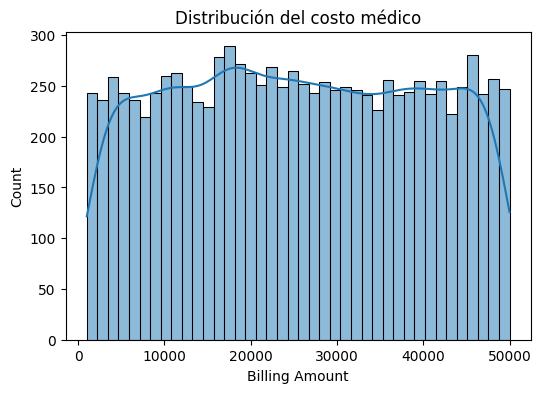

In [17]:
print(df['Billing Amount'].describe())

plt.figure(figsize=(6,4))
sns.histplot(df['Billing Amount'], bins=40, kde=True)
plt.title("Distribución del costo médico")
plt.show()

# Correlación del modeo

Admission Type_Emergency              -0.040940
Insurance Provider_Medicare           -0.017852
Medication_Penicillin                 -0.015671
Stay_Days                             -0.013507
Medication_Paracetamol                -0.013044
Medical Condition_Hypertension        -0.010212
Age                                   -0.009483
Test Results_Normal                   -0.009105
Insurance Provider_UnitedHealthcare   -0.003958
Medical Condition_Asthma              -0.003224
Medication_Ibuprofen                  -0.002741
Medical Condition_Cancer               0.000718
Insurance Provider_Blue Cross          0.004871
Insurance Provider_Cigna               0.005044
Medical Condition_Obesity              0.006396
Test Results_Inconclusive              0.007988
Medical Condition_Diabetes             0.017001
Medication_Lipitor                     0.021765
Admission Type_Urgent                  0.022611
Name: Billing Amount, dtype: float64


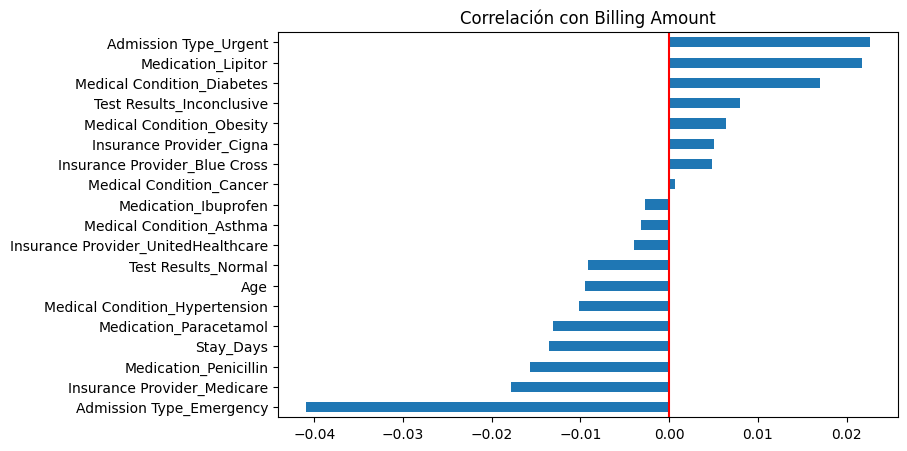

In [18]:
features = [
    'Age',
    'Stay_Days',
    'Medical Condition',
    'Admission Type',
    'Insurance Provider',
    'Medication',
    'Test Results'
]

df_model = df[features + ['Billing Amount']]

df_corr = pd.get_dummies(df_model, drop_first=True)

corr = df_corr.corr()['Billing Amount'].drop('Billing Amount').sort_values()

print(corr)

plt.figure(figsize=(8,5))
corr.plot(kind='barh')
plt.title("Correlación con Billing Amount")
plt.axvline(0, color='red')
plt.show()

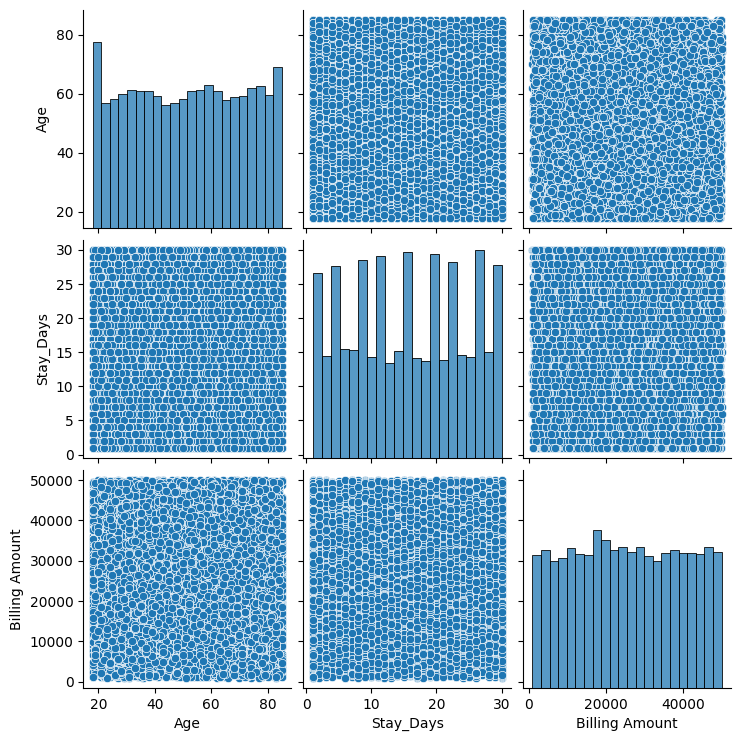

In [27]:
sns.pairplot(
    df[['Age', 'Stay_Days', 'Billing Amount']],
    diag_kind='hist'
)  #uso estas variables porque son numericas y tienen sentido compararlas e interpretarlas

plt.show()

# Modelo de Regresión Lineal

Entrenamos un modelo con sklearn para predecir el costo médico.

Luego lo comparamos con un modelo estadístico (OLS).

In [25]:
# otro metodo posible para practicas df_model = pd.get_dummies(df_model, drop_first=True)

categorical_cols = [
    'Medical Condition',
    'Admission Type',
    'Insurance Provider',
    'Medication',
    'Test Results'
]

numeric_cols = ['Age', 'Stay_Days']

# separar X e y primero
df_model = df[features + ['Billing Amount']]

# encoder
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

encoded_cat = encoder.fit_transform(df_model[categorical_cols])

encoded_cat = pd.DataFrame(
    encoded_cat,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=df_model.index
)

# unir numericas y categorticas codificadas
df_model_final = pd.concat(
    [df_model[numeric_cols], encoded_cat, df_model[['Billing Amount']]],
    axis=1
)

# limpiar
df_model_final = df_model_final.apply(pd.to_numeric, errors='coerce')
df_model_final = df_model_final.dropna()
X = df_model_final.drop(columns=['Billing Amount'])
y = df_model_final['Billing Amount']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R²: 0.002582576542972892
MAE: 12238.79866836499


#  Interpretación Estadística (OLS)

OLS nos permite ver:
- qué variables son significativas
- coeficientes
- p-values

Esto ayuda a entender el modelo, no solo predecir.

In [22]:
X_ols = sm.add_constant(X.astype(float))
ols = sm.OLS(y.astype(float), X_ols).fit()

print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:         Billing Amount   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.970
Date:                Tue, 14 Apr 2026   Prob (F-statistic):            0.00709
Time:                        17:26:49   Log-Likelihood:            -1.0969e+05
No. Observations:               10000   AIC:                         2.194e+05
Df Residuals:                    9980   BIC:                         2.196e+05
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
co

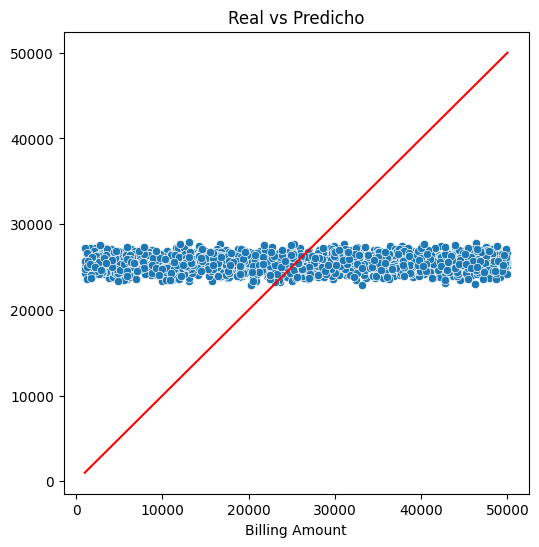

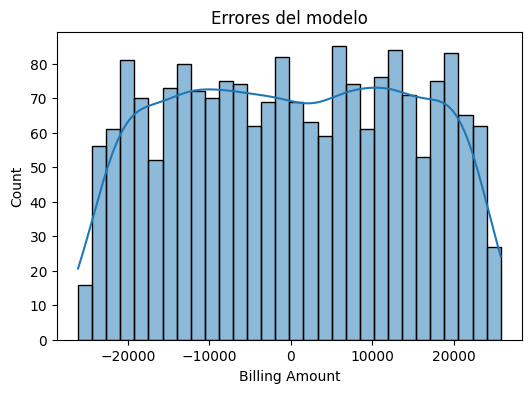

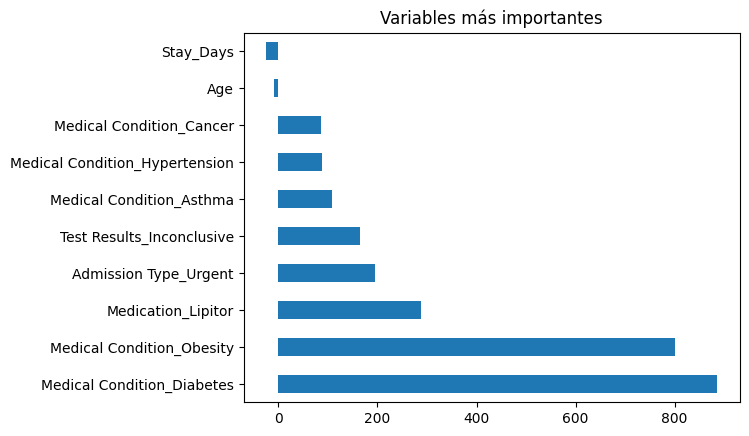

In [23]:
# Real vs predicho
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r')
plt.title("Real vs Predicho")
plt.show()

# errores
residuals = y_test - y_pred
plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Errores del modelo")
plt.show()

# importancia
coef = pd.Series(model.coef_, index=X.columns)
coef.nlargest(10).plot(kind='barh')
plt.title("Variables más importantes")
plt.show()

#  Diagnóstico del Modelo

Si el R² es bajo significa:

- Las variables no explican el costo
- No existe relación lineal fuerte
- El dataset puede ser sintético o incompleto

 **Importante**:
Un modelo no puede aprender patrones que no existen en los datos.

In [24]:
r2 = r2_score(y_test, y_pred)

print("\n DIAGNÓSTICO:")

if r2 < 0.05:
    print(" R cuadrado muy bajo: no hay señal predictiva en los datos.")
elif r2 < 0.3:
    print(" R cuadrado bajo: hay señal débil.")
else:
    print(" Buen modelo: hay patrones claros.")


 DIAGNÓSTICO:
 R cuadrado muy bajo: no hay señal predictiva en los datos.


# Conclusión final

El bajo rendimiento de los modelos no se debe a errores en la implementación, sino a una característica del dataset esto puede ser por falta de otros datos, o que estan generados sin una relación , si se usaran modelos no lineales como random forest u otros que se realizaron aparte de igual manera da un error media bastante bajo sin encontrar una relacion o patron claro de prediccion.